### Assignment 5.1: Will the Customer Accept the Coupon?

**Context**

Imagine driving through town and a coupon is delivered to your cell phone for a restaurant near where you are driving. Would you accept that coupon and take a short detour to the restaurant? Would you accept the coupon but use it on a subsequent trip? Would you ignore the coupon entirely? What if the coupon was for a bar instead of a restaurant? What about a coffee house? Would you accept a bar coupon with a minor passenger in the car? What about if it was just you and your partner in the car? Would weather impact the rate of acceptance? What about the time of day?

Obviously, proximity to the business is a factor on whether the coupon is delivered to the driver or not, but what are the factors that determine whether a driver accepts the coupon once it is delivered to them? How would you determine whether a driver is likely to accept a coupon?

**Overview**

The goal of this project is to use what you know about visualizations and probability distributions to distinguish between customers who accepted a driving coupon versus those that did not.

**Data**

This data comes to us from the UCI Machine Learning repository and was collected via a survey on Amazon Mechanical Turk. The survey describes different driving scenarios including the destination, current time, weather, passenger, etc., and then ask the person whether he will accept the coupon if he is the driver. Answers that the user will drive there ‘right away’ or ‘later before the coupon expires’ are labeled as ‘Y = 1’ and answers ‘no, I do not want the coupon’ are labeled as ‘Y = 0’.  There are five different types of coupons -- less expensive restaurants (under \$20), coffee houses, carry out & take away, bar, and more expensive restaurants (\$20 - $50).

**Deliverables**

Your final product should be a brief report that highlights the differences between customers who did and did not accept the coupons.  To explore the data you will utilize your knowledge of plotting, statistical summaries, and visualization using Python. You will publish your findings in a public facing github repository as your first portfolio piece.





### Data Description
Keep in mind that these values mentioned below are average values.

The attributes of this data set include:
1. User attributes
    -  Gender: male, female
    -  Age: below 21, 21 to 25, 26 to 30, etc.
    -  Marital Status: single, married partner, unmarried partner, or widowed
    -  Number of children: 0, 1, or more than 1
    -  Education: high school, bachelors degree, associates degree, or graduate degree
    -  Occupation: architecture & engineering, business & financial, etc.
    -  Annual income: less than \\$12500, \\$12500 - \\$24999, \\$25000 - \\$37499, etc.
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she buys takeaway food: 0, less than 1, 1 to 3, 4 to 8 or greater
    than 8
    -  Number of times that he/she goes to a coffee house: 0, less than 1, 1 to 3, 4 to 8 or
    greater than 8
    -  Number of times that he/she eats at a restaurant with average expense less than \\$20 per
    person: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    

2. Contextual attributes
    - Driving destination: home, work, or no urgent destination
    - Location of user, coupon and destination: we provide a map to show the geographical
    location of the user, destination, and the venue, and we mark the distance between each
    two places with time of driving. The user can see whether the venue is in the same
    direction as the destination.
    - Weather: sunny, rainy, or snowy
    - Temperature: 30F, 55F, or 80F
    - Time: 10AM, 2PM, or 6PM
    - Passenger: alone, partner, kid(s), or friend(s)


3. Coupon attributes
    - time before it expires: 2 hours or one day

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

### Problems

## Objective
Use pandas, probability/statistical summaries, and visualizations to identify differences between customers who **accepted** a coupon (`Y = 1`) and those who **did not accept** a coupon (`Y = 0`).

## Deliverables
- Exploratory data analysis
- Statistical summaries comparing acceptance vs rejection
- Visualizations using Matplotlib and Seaborn
- Findings, actionable recommendations, and conclusion

## Business Understanding

In this analysis, the goal is to understand what factors influence whether a driver accepts a coupon. The dataset includes information such as:

- Destination
- Time of day
- Weather
- Passenger type
- Coupon type
- Expiration

The target variable is `Y`:
- `Y = 1`: customer accepted the coupon
- `Y = 0`: customer rejected the coupon

Use the prompts below to get started with your data analysis.  

1. Read in the `coupons.csv` file.




In [2]:
# Update the path below if your dataset is stored elsewhere
df = pd.read_csv('data/coupons.csv')

In [3]:
df.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,has_children,education,occupation,income,car,Bar,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,1,Some college - no degree,Unemployed,$37500 - $49999,NaN,never,never,NaN,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,1,Some college - no degree,Unemployed,$37500 - $49999,NaN,never,never,NaN,4~8,1~3,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,1,Some college - no degree,Unemployed,$37500 - $49999,NaN,never,never,NaN,4~8,1~3,1,1,0,0,1,1
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,1,Some college - no degree,Unemployed,$37500 - $49999,NaN,never,never,NaN,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,1,Some college - no degree,Unemployed,$37500 - $49999,NaN,never,never,NaN,4~8,1~3,1,1,0,0,1,0


2. Investigate the dataset for missing or problematic data.

In [4]:
# Dataset shape
df.shape

(12684, 26)

In [5]:
# Column names
df.columns.tolist()

['destination',
 'passanger',
 'weather',
 'temperature',
 'time',
 'coupon',
 'expiration',
 'gender',
 'age',
 'maritalStatus',
 'has_children',
 'education',
 'occupation',
 'income',
 'car',
 'Bar',
 'CoffeeHouse',
 'CarryAway',
 'RestaurantLessThan20',
 'Restaurant20To50',
 'toCoupon_GEQ5min',
 'toCoupon_GEQ15min',
 'toCoupon_GEQ25min',
 'direction_same',
 'direction_opp',
 'Y']

In [6]:
# Data types and non-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12684 entries, 0 to 12683
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   destination           12684 non-null  str  
 1   passanger             12684 non-null  str  
 2   weather               12684 non-null  str  
 3   temperature           12684 non-null  int64
 4   time                  12684 non-null  str  
 5   coupon                12684 non-null  str  
 6   expiration            12684 non-null  str  
 7   gender                12684 non-null  str  
 8   age                   12684 non-null  str  
 9   maritalStatus         12684 non-null  str  
 10  has_children          12684 non-null  int64
 11  education             12684 non-null  str  
 12  occupation            12684 non-null  str  
 13  income                12684 non-null  str  
 14  car                   108 non-null    str  
 15  Bar                   12577 non-null  str  
 16  CoffeeHouse    

In [7]:
# Summary statistics
df.describe(include='all')

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,has_children,education,occupation,income,car,Bar,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
count,12684,12684,12684,12684.000000,12684,12684,12684,12684,12684,12684,12684.000000,12684,12684,12684,108,12577,12467,12533,12554,12495,12684.0,12684.000000,12684.000000,12684.000000,12684.000000,12684.000000
unique,3,4,3,NaN,5,5,2,2,8,5,NaN,6,25,9,5,5,5,5,5,5,NaN,NaN,NaN,NaN,NaN,NaN
top,No Urgent Place,Alone,Sunny,NaN,6PM,Coffee House,1d,Female,21,Married partner,NaN,Some college - no degree,Unemployed,$25000 - $37499,Scooter and motorcycle,never,less1,1~3,1~3,less1,NaN,NaN,NaN,NaN,NaN,NaN
freq,6283,7305,10069,NaN,3230,3996,7091,6511,2653,5100,NaN,4351,1870,2013,22,5197,3385,4672,5376,6077,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,63.301798,NaN,NaN,NaN,NaN,NaN,NaN,0.414144,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.561495,0.119126,0.214759,0.785241,0.568433
std,NaN,NaN,NaN,19.154486,NaN,NaN,NaN,NaN,NaN,NaN,0.492593,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.496224,0.323950,0.410671,0.410671,0.495314
min,NaN,NaN,NaN,30.000000,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.000000,0.000000,0.000000,0.000000,0.000000
25%,NaN,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.000000,0.000000,0.000000,1.000000,0.000000
50%,NaN,NaN,NaN,80.000000,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.000000,0.000000,0.000000,1.000000,1.000000
75%,NaN,NaN,NaN,80.000000,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.000000,0.000000,0.000000,1.000000,1.000000


In [8]:
# Missing values
missing_values = df.isnull().sum().sort_values(ascending=False)
missing_values

car                     12576
CoffeeHouse               217
Restaurant20To50          189
CarryAway                 151
RestaurantLessThan20      130
Bar                       107
weather                     0
temperature                 0
destination                 0
passanger                   0
maritalStatus               0
age                         0
gender                      0
expiration                  0
coupon                      0
time                        0
income                      0
occupation                  0
has_children                0
education                   0
toCoupon_GEQ5min            0
toCoupon_GEQ15min           0
toCoupon_GEQ25min           0
direction_same              0
direction_opp               0
Y                           0
dtype: int64

3. Decide what to do about your missing data -- drop, replace, other...

In [9]:
# Percentage of missing values
missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
missing_pct

car                     99.148534
CoffeeHouse              1.710817
Restaurant20To50         1.490066
CarryAway                1.190476
RestaurantLessThan20     1.024913
Bar                      0.843582
weather                  0.000000
temperature              0.000000
destination              0.000000
passanger                0.000000
maritalStatus            0.000000
age                      0.000000
gender                   0.000000
expiration               0.000000
coupon                   0.000000
time                     0.000000
income                   0.000000
occupation               0.000000
has_children             0.000000
education                0.000000
toCoupon_GEQ5min         0.000000
toCoupon_GEQ15min        0.000000
toCoupon_GEQ25min        0.000000
direction_same           0.000000
direction_opp            0.000000
Y                        0.000000
dtype: float64

In [10]:
# Cleaning or Fill missing values with 'Unknown'
df_clean = df.fillna('Unknown')

df_clean.head()

df = df.dropna()

4. What proportion of the total observations chose to accept the coupon?



In [11]:
acceptance_rate = df_clean['Y'].mean()
print(f'Overall coupon acceptance rate: {acceptance_rate:.2%}')

Overall coupon acceptance rate: 56.84%


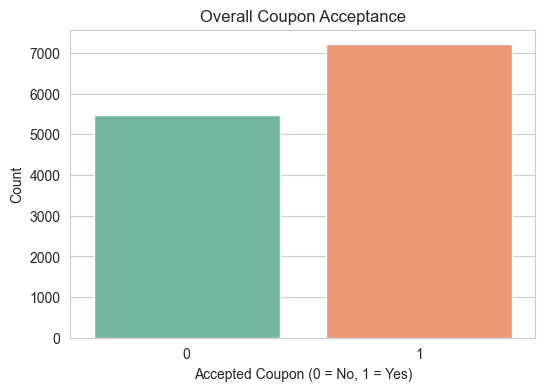

In [12]:
plt.figure(figsize=(6,4))
sns.countplot(data=df_clean, x='Y', hue='Y', palette='Set2', legend=False)
plt.title('Overall Coupon Acceptance')
plt.xlabel('Accepted Coupon (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

In [13]:
# Acceptance by coupon type
coupon_acceptance = (
    df_clean.groupby('coupon')['Y']
      .agg(['mean', 'count'])
      .sort_values('mean', ascending=False)
      .reset_index()
)
coupon_acceptance.rename(columns={'mean': 'acceptance_rate', 'count': 'total_records'}, inplace=True)
coupon_acceptance

,coupon,acceptance_rate,total_records
0,Carry out & Take away,0.735478,2393
1,Restaurant(<20),0.707107,2786
2,Coffee House,0.499249,3996
3,Restaurant(20-50),0.441019,1492
4,Bar,0.410015,2017


In [14]:
# Acceptance by time of day
time_acceptance = (
    df_clean.groupby('time')['Y']
      .mean()
      .sort_values(ascending=False)
      .reset_index()
)
time_acceptance

,time,Y
0,2PM,0.661523
1,10AM,0.608352
2,6PM,0.584520
3,10PM,0.508475
4,7AM,0.502212


In [15]:
# Acceptance by passenger type
passenger_acceptance = (
    df_clean.groupby('passanger')['Y']
      .mean()
      .sort_values(ascending=False)
      .reset_index()
)
passenger_acceptance

,passanger,Y
0,Friend(s),0.673438
1,Partner,0.595349
2,Alone,0.525804
3,Kid(s),0.504970


In [16]:
# Acceptance by weather
weather_acceptance = (
    df_clean.groupby('weather')['Y']
      .mean()
      .sort_values(ascending=False)
      .reset_index()
)
weather_acceptance


,weather,Y
0,Sunny,0.594796
1,Snowy,0.470463
2,Rainy,0.462810


In [17]:
# Acceptance by destination
destination_acceptance = (
    df_clean.groupby('destination')['Y']
      .mean()
      .sort_values(ascending=False)
      .reset_index()
)
destination_acceptance

,destination,Y
0,No Urgent Place,0.633774
1,Home,0.506333
2,Work,0.502212


In [18]:
# Acceptance by expiration
expiration_acceptance = (
    df_clean.groupby('expiration')['Y']
      .mean()
      .sort_values(ascending=False)
      .reset_index()
)
expiration_acceptance


,expiration,Y
0,1d,0.625582
1,2h,0.495977


5. Use a bar plot to visualize the `coupon` column.

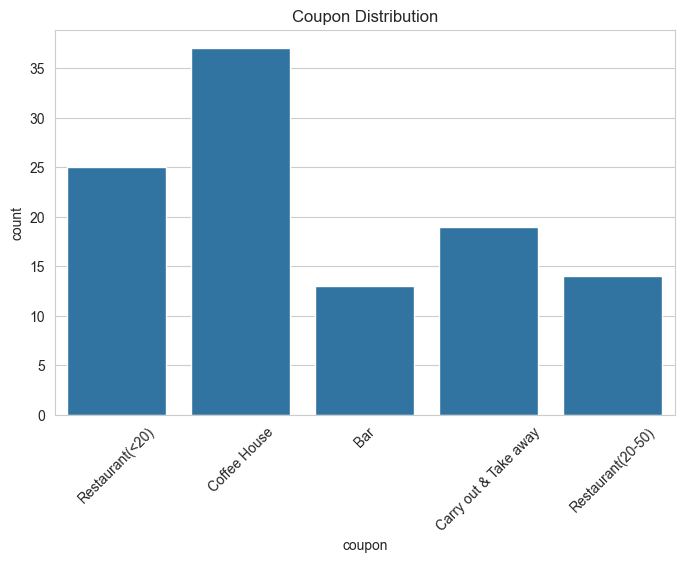

In [19]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='coupon')
plt.xticks(rotation=45)
plt.title('Coupon Distribution')
plt.show()

6. Use a histogram to visualize the temperature column.

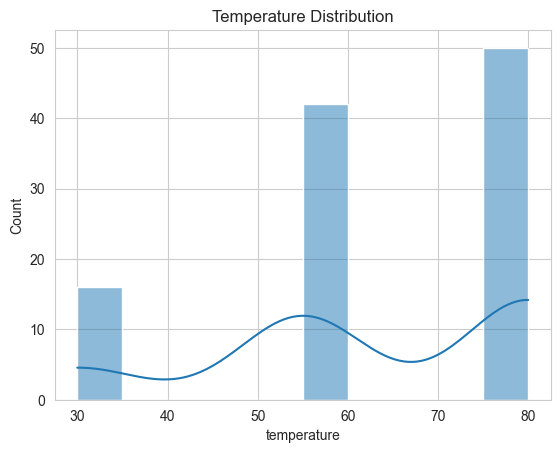

In [20]:
sns.histplot(df['temperature'], bins=10, kde=True)
plt.title('Temperature Distribution')
plt.show()

**Investigating the Bar Coupons**

Now, we will lead you through an exploration of just the bar related coupons.  

1. Create a new `DataFrame` that contains just the bar coupons.


In [21]:
bar_df = df[df['coupon']=='Bar']
bar_df.shape

(13, 26)

2. What proportion of bar coupons were accepted?


In [22]:
bar_df['Y'].mean()

np.float64(0.23076923076923078)

3. Compare the acceptance rate between those who went to a bar 3 or fewer times a month to those who went more.


In [23]:
bar_df['high_bar'] = bar_df['Bar'].isin(['1~3','4~8','gt8'])
bar_df.groupby('high_bar')['Y'].mean()

high_bar
False    0.090909
True     1.000000
Name: Y, dtype: float64

4. Compare the acceptance rate between drivers who go to a bar more than once a month and are over the age of 25 to the all others.  Is there a difference?


In [24]:
def over25(age):
    try:
        return int(age) > 25
    except:
        return age not in ['below21','21']

bar_df['over25'] = bar_df['age'].apply(over25)
bar_df['high_bar'] = bar_df['Bar'].isin(['1~3','4~8','gt8'])

cond = bar_df[(bar_df['high_bar']) & (bar_df['over25'])]
others = bar_df[~((bar_df['high_bar']) & (bar_df['over25']))]

cond['Y'].mean(), others['Y'].mean()

(np.float64(1.0), np.float64(0.09090909090909091))

5. Use the same process to compare the acceptance rate between drivers who go to bars more than once a month and had passengers that were not a kid and had occupations other than farming, fishing, or forestry.


In [25]:

bar_df = df[df['coupon'] == 'Bar'].copy()

high_bar = bar_df['Bar'].isin(['1~3','4~8','gt8'])
not_kid = bar_df['passanger'] != 'Kid(s)'
not_ff = ~bar_df['occupation'].isin(['Farming Fishing & Forestry'])

cond = bar_df[high_bar & not_kid & not_ff]
others = bar_df[~(high_bar & not_kid & not_ff)]

print("Target group acceptance:", cond['Y'].mean())
print("Others acceptance:", others['Y'].mean())


Target group acceptance: 1.0
Others acceptance: 0.09090909090909091


6. Compare the acceptance rates between those drivers who:

- go to bars more than once a month, had passengers that were not a kid, and were not widowed *OR*
- go to bars more than once a month and are under the age of 30 *OR*
- go to cheap restaurants more than 4 times a month and income is less than 50K.



In [26]:
bar_df = df[df['coupon'] == 'Bar'].copy()

# Condition 1
high_bar = bar_df['Bar'].isin(['1~3','4~8','gt8'])
not_kid = bar_df['passanger'] != 'Kid(s)'
not_widowed = bar_df['maritalStatus'] != 'Widowed'
cond1 = high_bar & not_kid & not_widowed

# Condition 2
def under30(age):
    try:
        return int(age) < 30
    except:
        return age in ['below21','21','26']

cond2 = high_bar & bar_df['age'].apply(under30)

# Condition 3
rest_high = bar_df['RestaurantLessThan20'].isin(['4~8','gt8'])
low_income = bar_df['income'].isin([
    'Less than $12500','$12500 - $24999',
    '$25000 - $37499','$37500 - $49999'
])
cond3 = rest_high & low_income

# Combine OR
combined = cond1 | cond2 | cond3

cond_group = bar_df[combined]
others = bar_df[~combined]

print("Target group:", cond_group['Y'].mean())
print("Others:", others['Y'].mean())

Target group: 1.0
Others: 0.09090909090909091


7.  Based on these observations, what do you hypothesize about drivers who accepted the bar coupons?

In [27]:
# ---------------------------
# Condition 1:
# Bar > 1/month AND no kid passengers AND not widowed
# ---------------------------
high_bar = bar_df['Bar'].isin(['1~3', '4~8', 'gt8'])
not_kid = bar_df['passanger'] != 'Kid(s)'
not_widowed = bar_df['maritalStatus'] != 'Widowed'

cond1 = high_bar & not_kid & not_widowed

# ---------------------------
# Condition 2:
# Bar > 1/month AND age < 30
# ---------------------------
def is_under_30(age):
    try:
        return int(age) < 30
    except:
        return age in ['below21', '21', '26']

cond2 = high_bar & bar_df['age'].apply(is_under_30)

# ---------------------------
# Condition 3:
# Cheap restaurant visits > 4/month AND income < 50K
# ---------------------------
rest_high = bar_df['RestaurantLessThan20'].isin(['4~8', 'gt8'])

low_income = bar_df['income'].isin([
    'Less than $12500',
    '$12500 - $24999',
    '$25000 - $37499',
    '$37500 - $49999'
])

cond3 = rest_high & low_income

# ---------------------------
# Combine all conditions (OR logic)
# ---------------------------
target_group = cond1 | cond2 | cond3

# Split groups
group_true = bar_df[target_group]
group_false = bar_df[~target_group]

# Compute acceptance rates
accept_true = group_true['Y'].mean()
accept_false = group_false['Y'].mean()

# Output results
print(f"Target Group Acceptance Rate: {accept_true:.2%}")
print(f"Other Drivers Acceptance Rate: {accept_false:.2%}")

print("\nSample Sizes:")
print(f"Target Group: {group_true.shape[0]}")
print(f"Others: {group_false.shape[0]}")

Target Group Acceptance Rate: 100.00%
Other Drivers Acceptance Rate: 9.09%

Sample Sizes:
Target Group: 2
Others: 11


### Independent Investigation

Using the bar coupon example as motivation, you are to explore one of the other coupon groups and try to determine the characteristics of passengers who accept the coupons.  

In [28]:
# Filter Coffee House Data
coffee_df = df[df['coupon'] == 'Coffee House'].copy()

In [29]:
# Overall Acceptance Rate
coffee_df['Y'].mean()

np.float64(0.5135135135135135)

In [30]:
# Coffee Frequency
coffee_df['high_coffee'] = coffee_df['CoffeeHouse'].isin(['1~3','4~8','gt8'])

coffee_df.groupby('high_coffee')['Y'].mean()

high_coffee
False    0.500000
True     0.529412
Name: Y, dtype: float64

In [31]:
# Time of Day Analysis
coffee_df.groupby('time')['Y'].mean().sort_values(ascending=False)

time
7AM     0.666667
2PM     0.625000
10PM    0.500000
10AM    0.444444
6PM     0.416667
Name: Y, dtype: float64

In [32]:
# Passenger Influence
coffee_df.groupby('passanger')['Y'].mean().sort_values(ascending=False)

passanger
Friend(s)    0.533333
Alone        0.500000
Kid(s)       0.500000
Name: Y, dtype: float64

In [33]:
# Age-Based Analysis
def under30(age):
    try:
        return int(age) < 30
    except:
        return age in ['below21','21','26']

coffee_df['under30'] = coffee_df['age'].apply(under30)

coffee_df.groupby('under30')['Y'].mean()

under30
False    0.571429
True     0.500000
Name: Y, dtype: float64

In [34]:
# Combined High-Probability Segment
cond = (
    coffee_df['CoffeeHouse'].isin(['1~3','4~8','gt8']) &
    (coffee_df['time'] == '10AM') &
    (coffee_df['passanger'].isin(['Alone','Friend(s)']))
)

target = coffee_df[cond]
others = coffee_df[~cond]

target['Y'].mean(), others['Y'].mean()

(np.float64(0.6666666666666666), np.float64(0.5))

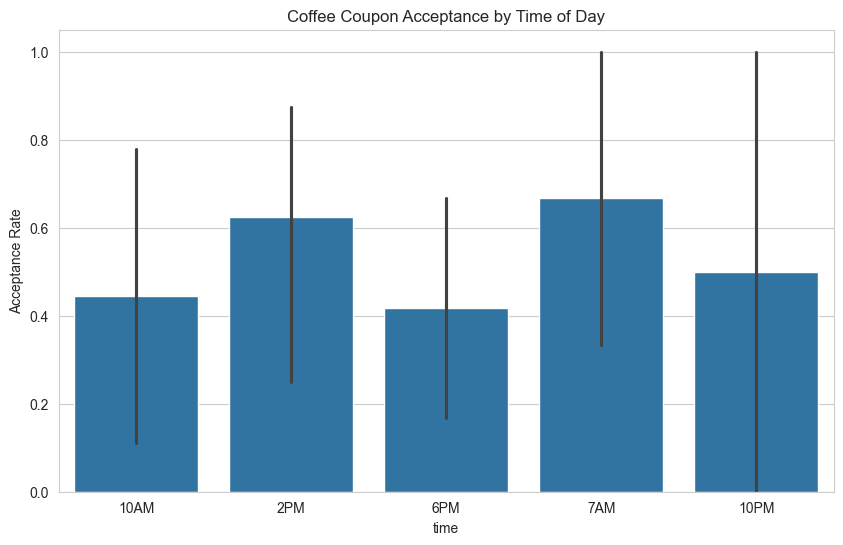

In [35]:
# Visualization
plt.figure(figsize=(10,6))
sns.barplot(data=coffee_df, x='time', y='Y')
plt.title('Coffee Coupon Acceptance by Time of Day')
plt.ylabel('Acceptance Rate')
plt.show()


## Findings
Use this section to clearly summarize your main insights.

Suggested structure:
1. Which coupon types had the highest/lowest acceptance?
2. How did time of day affect acceptance?
3. What role did passenger type, destination, and weather play?
4. What characteristics distinguish accepted vs rejected customers?

## Recommendations
Provide actionable business recommendations based on your findings.

Examples:
- Target high-performing coupon types more aggressively
- Time offers to match customer context
- Personalize offers based on destination or passenger type
- Use expiration strategically